# Creating the datasets for the experiments.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets
from torchvision import transforms
from einops import rearrange

The dataset creation pipeline is as follows:

* Split the training set into local training sets and proxy dataset
* Save the images already normalised
* Extract the information related to the dataset (e.g., min and max intensities)

Enter the dataset destination below:

In [15]:
OUTPUT_PATH = 'data/'

os.makedirs('tmp', exist_ok=True)

## Functions

In [13]:
def dataset_to_dict(dataset):
    _dict = { 'images': [], 'labels': [] }
    for i in range(len(dataset)):
        image, label = dataset[i]
        _dict['images'].append(image.unsqueeze(0))
        _dict['labels'].append(torch.tensor([label]))
    _dict['images'] = torch.cat(_dict['images'])
    _dict['labels'] = torch.cat(_dict['labels'])
    return _dict


def create_proxy_dataset(trainset, proxy_fraction: float, validation_fraction: float):
    num_samples = len(trainset)
    indices = np.arange(num_samples)
    np.random.shuffle(indices)

    proxy_size = int(proxy_fraction * num_samples)
    validation_size = int(validation_fraction * num_samples)

    proxy_indices = indices[:proxy_size]
    validation_indices = indices[proxy_size:proxy_size + validation_size]
    remaining_indices = indices[proxy_size + validation_size:]

    proxy_dataset = Subset(trainset, proxy_indices)
    validation_dataset = Subset(trainset, validation_indices)
    remaining_dataset = Subset(trainset, remaining_indices)

    return proxy_dataset, validation_dataset, remaining_dataset


def create_iid_split(dataset: Dataset, num_clients: int):
    """Creates an IID split among clients."""
    indices = np.arange(len(dataset))
    np.random.shuffle(indices)
    client_splits = np.array_split(indices, num_clients)
    return [Subset(dataset, split) for split in client_splits]


def create_weak_noniid_split(dataset: Dataset, num_clients: int, num_classes: int, alpha: float = 0.5):
    """Creates a weak non-IID split using a Dirichlet distribution."""
    targets = np.array(dataset.dataset.targets)[dataset.indices] \
            if isinstance(dataset, Subset) else np.array(dataset.targets)
    class_indices = [np.where(targets == i)[0] for i in range(num_classes)]
    
    # Use Dirichlet distribution to allocate samples
    client_indices = [[] for _ in range(num_clients)]
    for c, class_idx in enumerate(class_indices):
        np.random.shuffle(class_idx)
        proportions = np.random.dirichlet(alpha=[alpha] * num_clients)
        proportions = (proportions * len(class_idx)).astype(int)

        start_idx = 0
        for client_id, num_samples in enumerate(proportions):
            client_indices[client_id].extend(class_idx[start_idx:start_idx + num_samples])
            start_idx += num_samples

    return [Subset(dataset, indices) for indices in client_indices]


def create_strong_noniid_split(dataset: Dataset, num_clients: int, num_classes: int):
    """Creates a strong non-IID split with one class per client."""
    assert num_clients <= num_classes, "Number of clients must not exceed number of classes"
    targets = np.array(dataset.dataset.targets)[dataset.indices] \
            if isinstance(dataset, Subset) else np.array(dataset.targets)
    class_indices = [np.where(targets == i)[0] for i in range(num_classes)]
    client_splits = [Subset(dataset, class_indices[i]) for i in range(num_clients)]
    return client_splits

def visualise_proxy_and_clients(proxyset_d, clients_local_sets_d, partitions_type: str):
    """
    Visualize the distribution of labels in the proxy dataset and client datasets.

    Parameters:
    - proxyset_d (dict): Dictionary containing the proxy dataset, with key 'labels' holding label tensors.
    - clients_local_sets_d (list of dict): List of dictionaries, each representing a client dataset, with key 'labels'.
    - partitions_type (str): A title for the visualization describing the partitioning method (e.g., IID, weak non-IID).
    """
    data = [{'from': 'proxy', 'label': label.item()} for label in proxyset_d['labels']]
    for idx, local_set in enumerate(clients_local_sets_d):
        data += [{'from': f'client-{idx}', 'label': label.item()} for label in local_set['labels']]

    df = pd.DataFrame(data)
    
    fig, ax = plt.subplots(ncols=11, figsize=(20, 3))
    for ax_idx in range(11):
        if ax_idx == 10:
            subset = df[df['from'] == 'proxy']
            title = 'Proxy'
        else:  # Handle client datasets
            subset = df[df['from'] == f'client-{ax_idx}']
            title = f'Client-{ax_idx}'
        
        # Group by label and count occurrences
        label_counts = subset.groupby('label').size().reset_index(name='count')
        
        # Plot bar chart
        ax[ax_idx].bar(label_counts['label'], label_counts['count'])
        ax[ax_idx].set_xticks(range(10))
        ax[ax_idx].set_xticklabels(range(10))
        ax[ax_idx].spines[['right', 'top']].set_visible(False)
        ax[ax_idx].set_title(title)
    
    # Add overall title and adjust layout
    plt.suptitle(partitions_type, fontsize=16)
    plt.tight_layout()
    plt.show()


def visualize_proxy_and_clients_images(proxyset_d, clients_local_sets_d, partitions_type: str):
    """
    """
    def randomload(_dict):
        img = _dict['images'][ np.random.randint(0, _dict['images'].shape[0]) ].numpy()
        img = rearrange(img, "C H W -> H W C")
        img = (img - img.min()) / (img.max() - img.min())
        return img
    
    fig, ax = plt.subplots(ncols=11, figsize=(20, 3))
    for ax_idx in range(11):
        if ax_idx == 10:
            img = randomload(proxyset_d)
            title = 'Proxy'
        else:  # Handle client datasets
            img = randomload(clients_local_sets_d[ax_idx])
            title = f'Client-{ax_idx}'
        
        # Plot bar chart
        ax[ax_idx].imshow(img)
        ax[ax_idx].set_axis_off()
        ax[ax_idx].set_title(title)
    
    # Add overall title and adjust layout
    plt.suptitle(partitions_type, fontsize=16)
    plt.tight_layout()
    plt.show()
    
    
def do(trainset, testset, output_path):
    """
    """
    proxyset, validset, set_to_distribute = create_proxy_dataset(trainset, proxy_fraction=0.2, validation_fraction=0.05)

    validset_d = dataset_to_dict(validset)
    proxyset_d = dataset_to_dict(proxyset)
    testset_d = dataset_to_dict(testset)

    clients_local_sets_iid = create_iid_split(set_to_distribute, num_clients=10)
    clients_local_sets_wni = create_weak_noniid_split(set_to_distribute, num_clients=10, num_classes=10, alpha=10)
    clients_local_sets_hni = create_weak_noniid_split(set_to_distribute, num_clients=10, num_classes=10, alpha=.1)
    clients_local_sets_xni = create_strong_noniid_split(set_to_distribute, num_clients=10, num_classes=10) 

    clients_local_sets_iid_d = [ dataset_to_dict(d) for d in clients_local_sets_iid ]
    clients_local_sets_wni_d = [ dataset_to_dict(d) for d in clients_local_sets_wni ]
    clients_local_sets_hni_d = [ dataset_to_dict(d) for d in clients_local_sets_hni ]
    clients_local_sets_xni_d = [ dataset_to_dict(d) for d in clients_local_sets_xni ]
    
    visualise_proxy_and_clients(proxyset_d, clients_local_sets_iid_d, 'IID')
    visualise_proxy_and_clients(testset_d, clients_local_sets_wni_d, 'Weak non-IID')
    visualise_proxy_and_clients(validset_d, clients_local_sets_hni_d, 'Strong non-IID')
    visualise_proxy_and_clients(testset_d, clients_local_sets_xni_d, 'eXtreme non-IID')
    
    visualize_proxy_and_clients_images(proxyset_d, clients_local_sets_iid_d, 'IID')
    visualize_proxy_and_clients_images(testset_d, clients_local_sets_wni_d, 'Weak non-IID')
    visualize_proxy_and_clients_images(validset_d, clients_local_sets_hni_d, 'Strong non-IID')
    visualize_proxy_and_clients_images(proxyset_d, clients_local_sets_xni_d, 'eXtreme non-IID')
    
    torch.save({
        'local_sets_iid': clients_local_sets_iid_d,
        'local_sets_wni': clients_local_sets_wni_d,
        'local_sets_hni': clients_local_sets_hni_d,
        'local_sets_xni': clients_local_sets_xni_d,
        'proxy_set': proxyset_d,
        'valid_set': validset_d,
        'test_set': testset_d,
    },  output_path)

## CIFAR-10

Files already downloaded and verified
Files already downloaded and verified


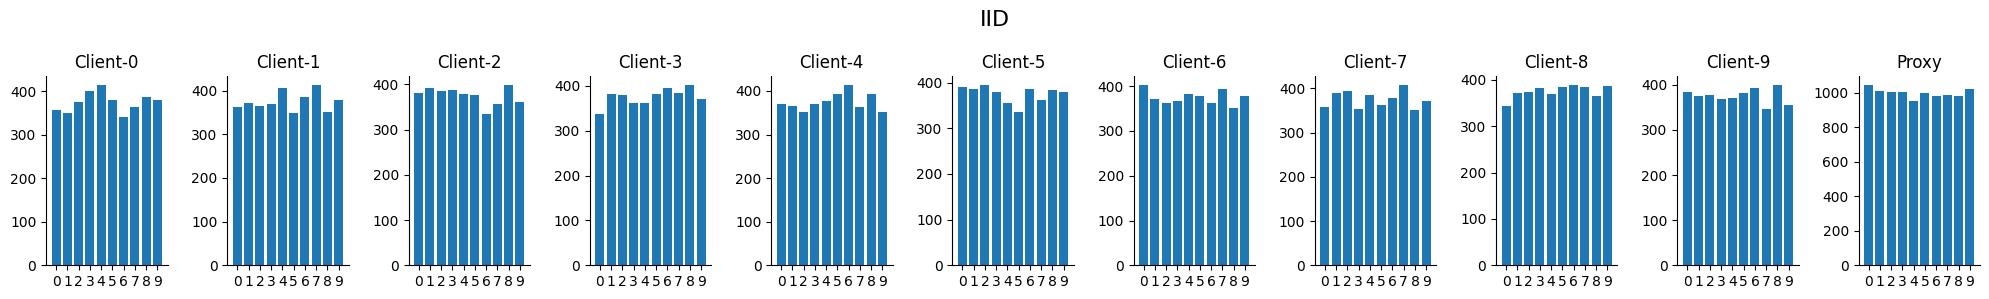

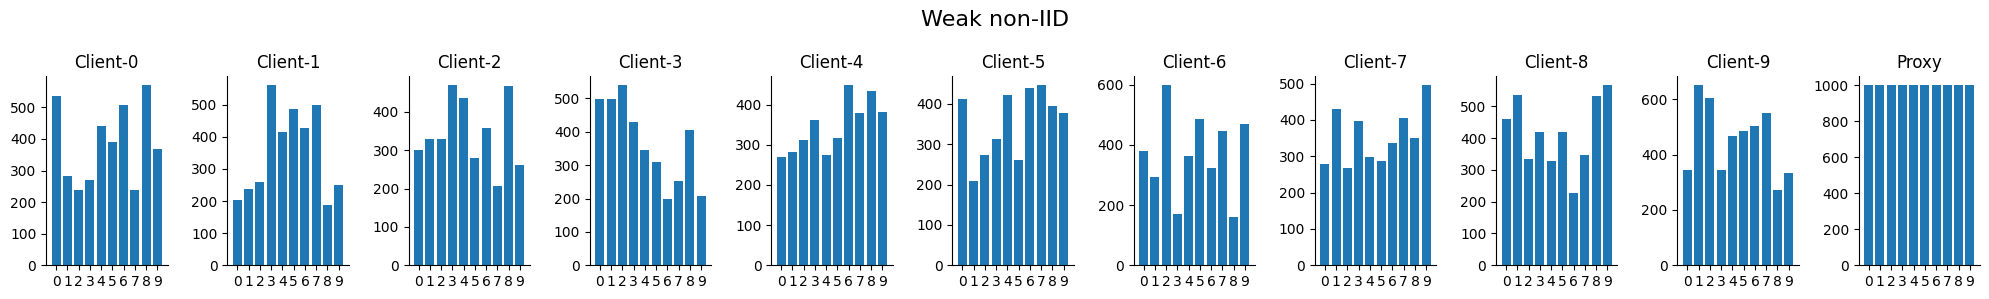

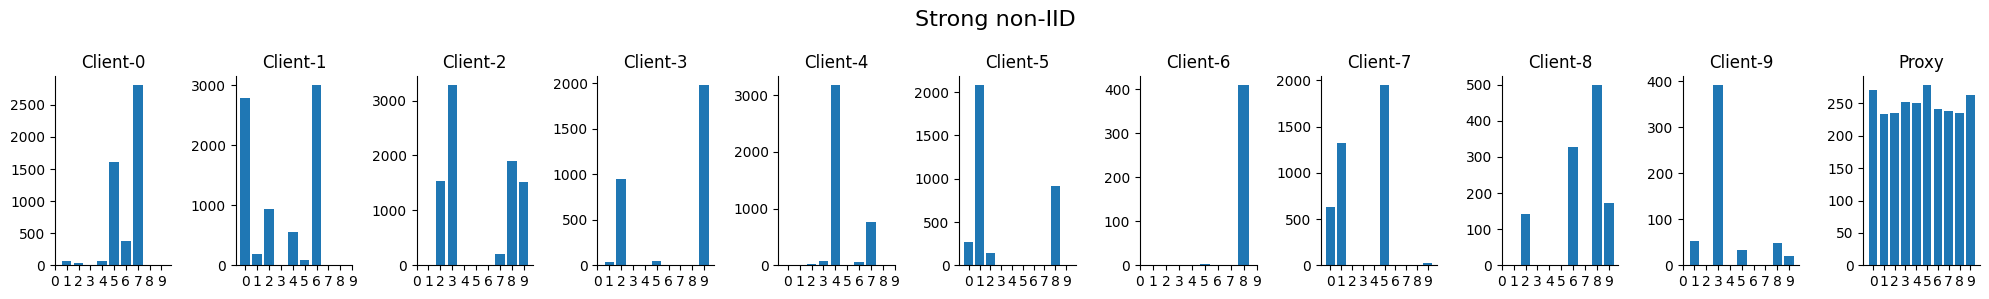

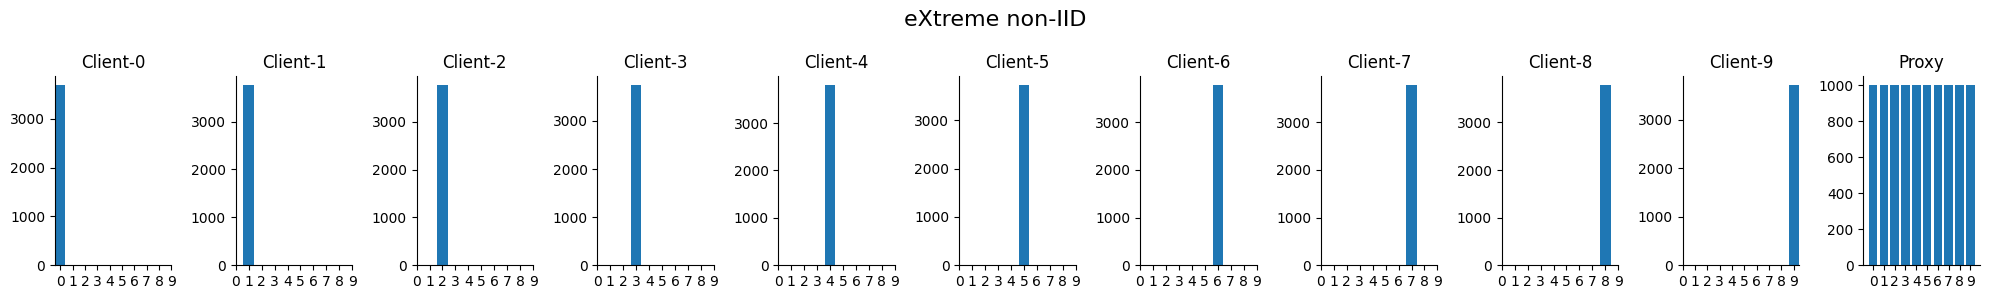

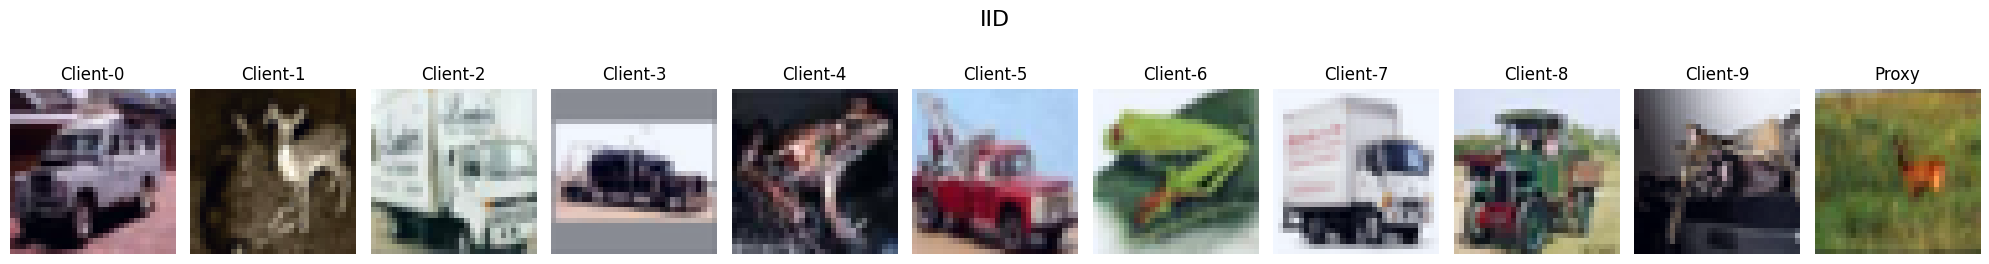

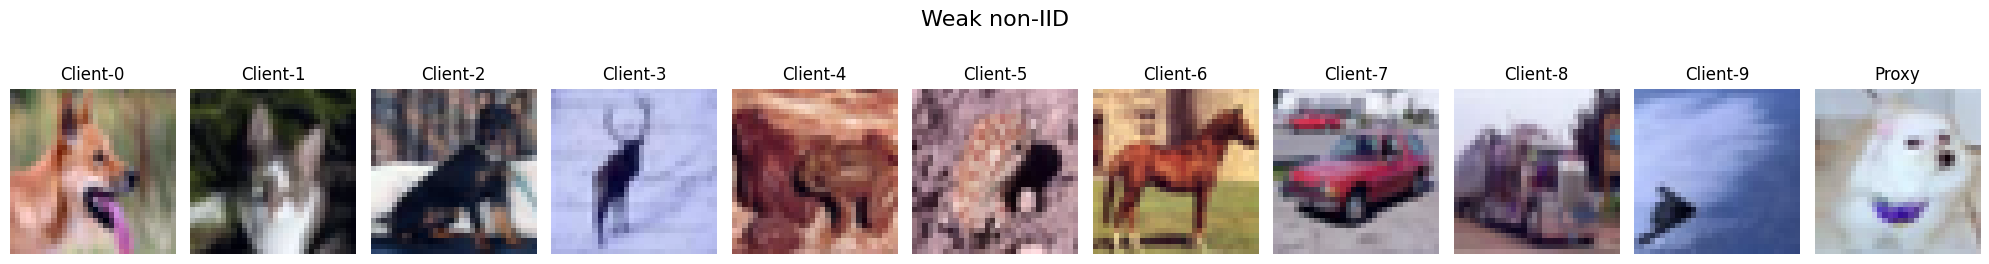

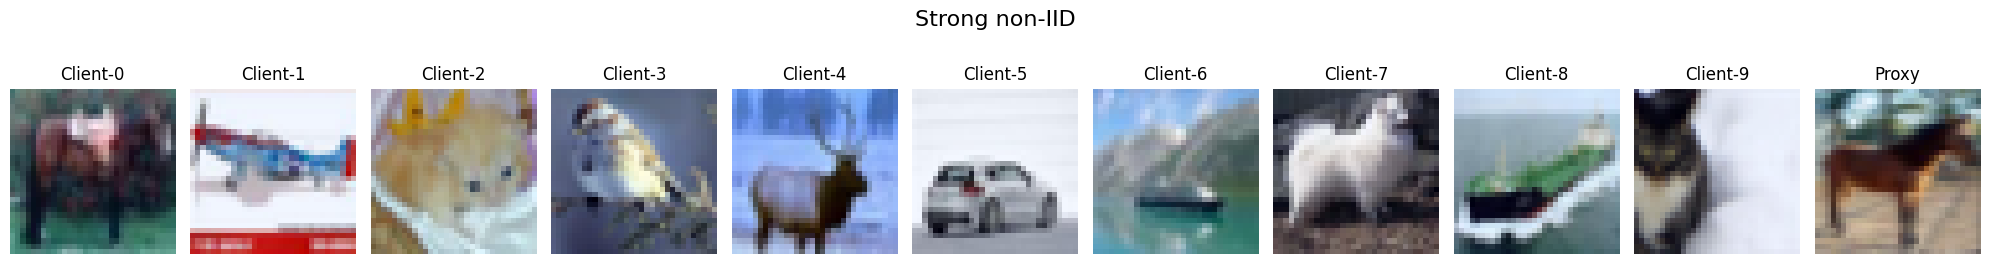

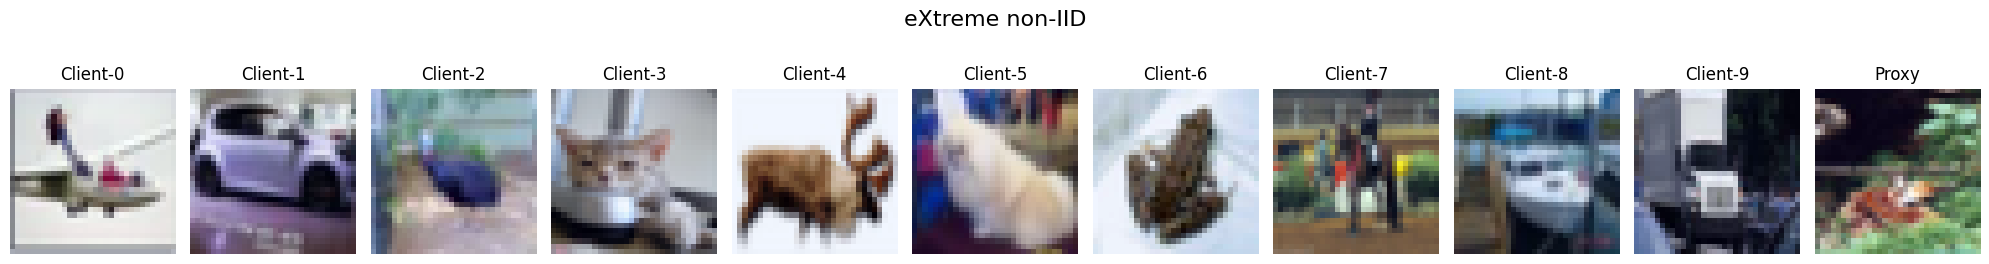

In [16]:
os.makedirs('tmp/CIFAR10', exist_ok=True)

transforms_fn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

cifar10 = datasets.CIFAR10(root='tmp/CIFAR10', train=True, transform=transforms_fn, download=True)
cifar10_test = datasets.CIFAR10(root='tmp/CIFAR10', train=False, transform=transforms_fn, download=True)

do(cifar10, cifar10_test, os.path.join(OUTPUT_PATH, 'cifar10.pt'))

## MNIST

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:05<00:00, 1.72MB/s]


Extracting tmp/MNIST/MNIST/raw/train-images-idx3-ubyte.gz to tmp/MNIST/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 203kB/s]


Extracting tmp/MNIST/MNIST/raw/train-labels-idx1-ubyte.gz to tmp/MNIST/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]


Extracting tmp/MNIST/MNIST/raw/t10k-images-idx3-ubyte.gz to tmp/MNIST/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 586kB/s]


Extracting tmp/MNIST/MNIST/raw/t10k-labels-idx1-ubyte.gz to tmp/MNIST/MNIST/raw



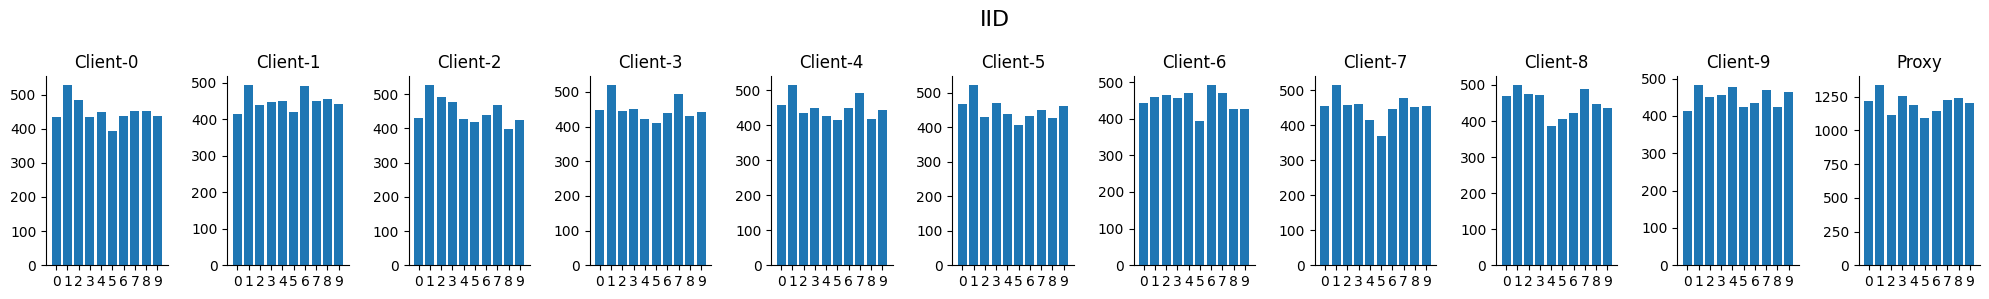

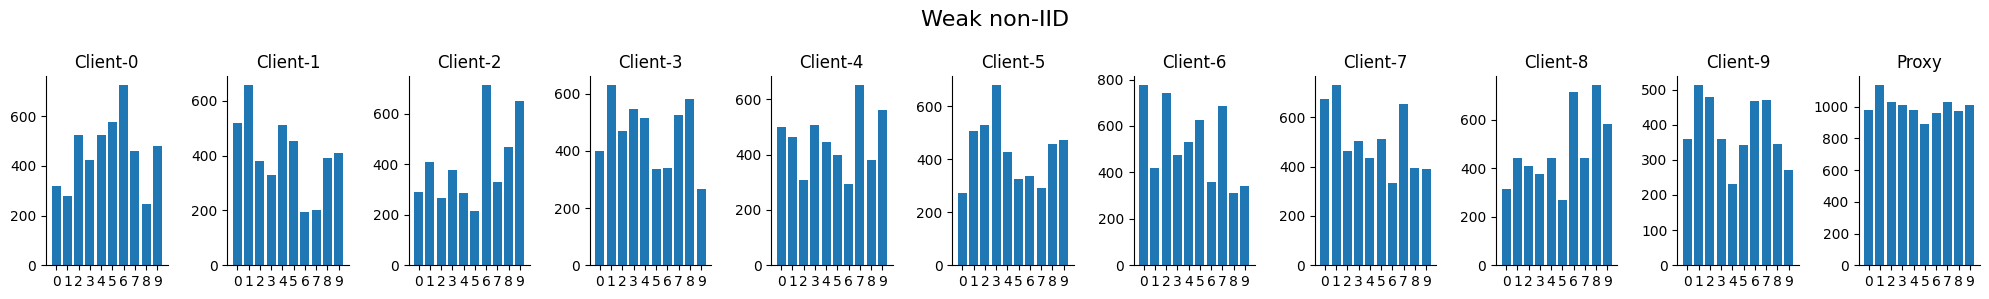

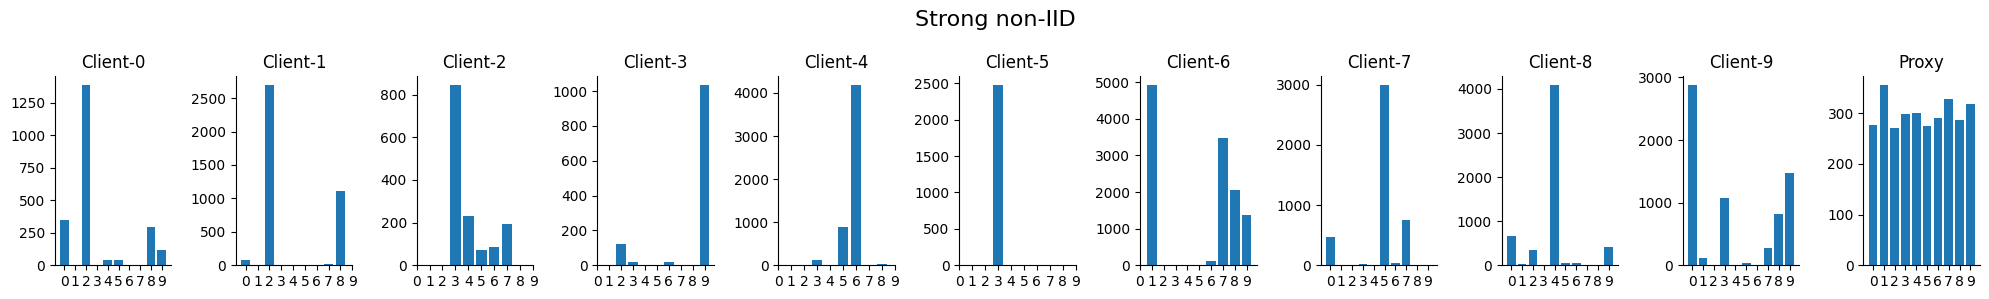

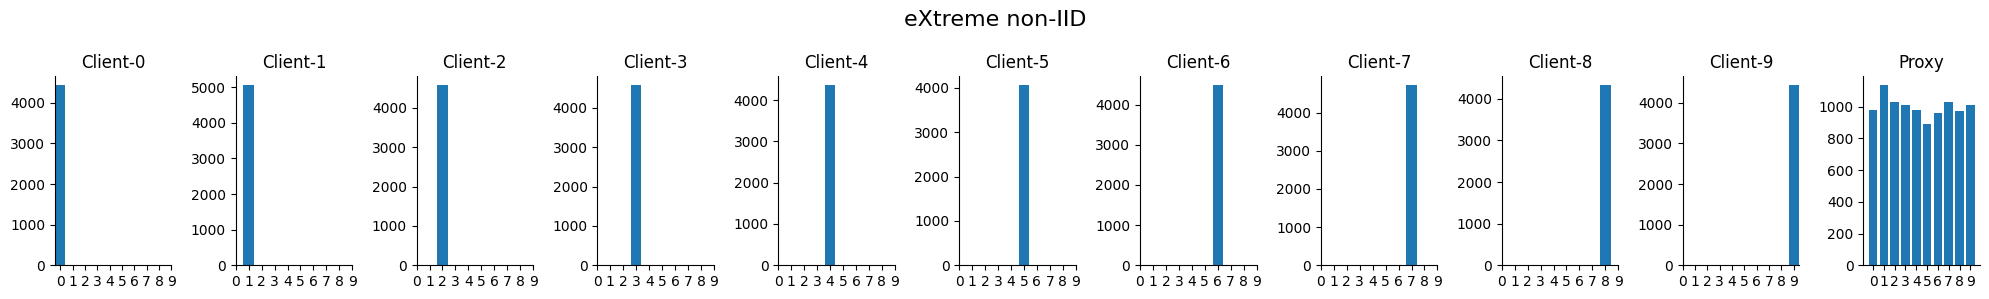

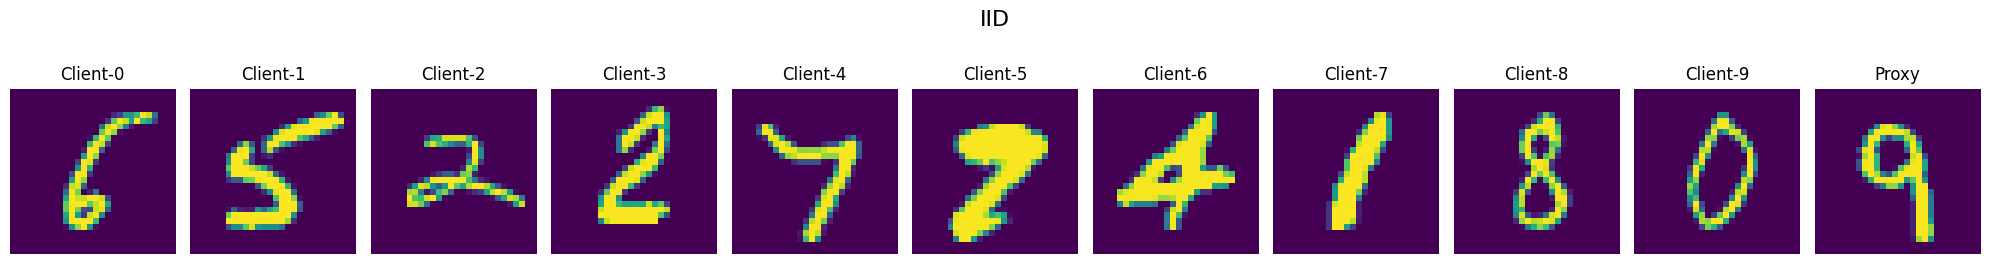

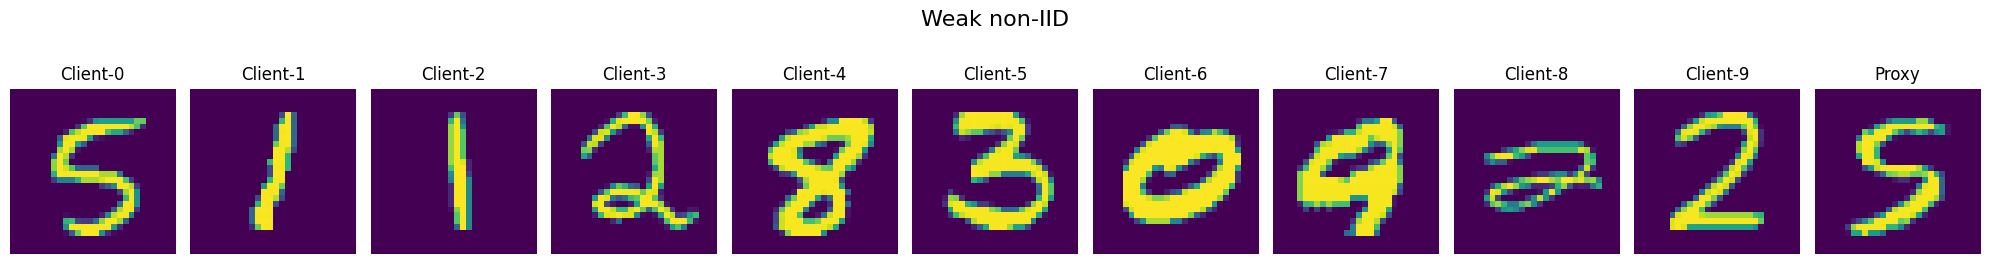

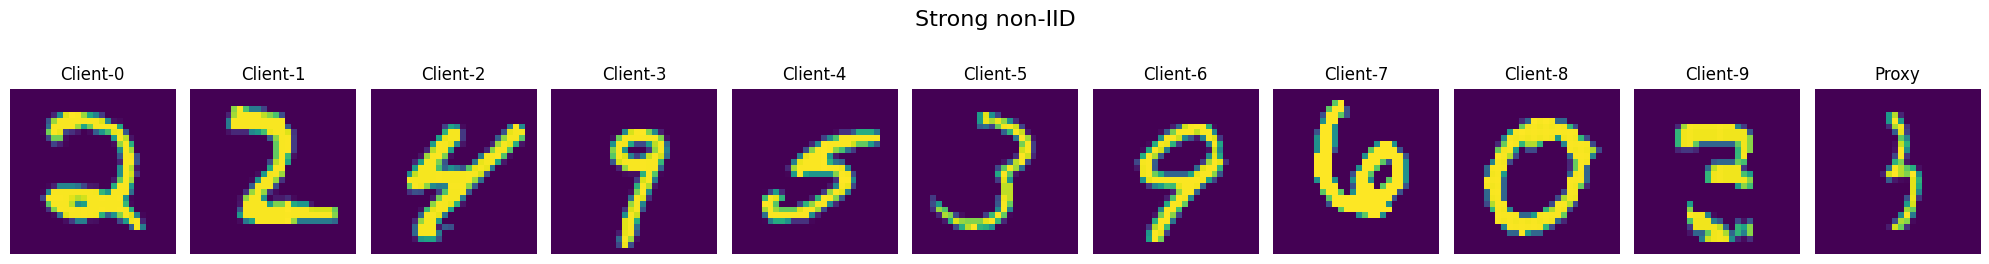

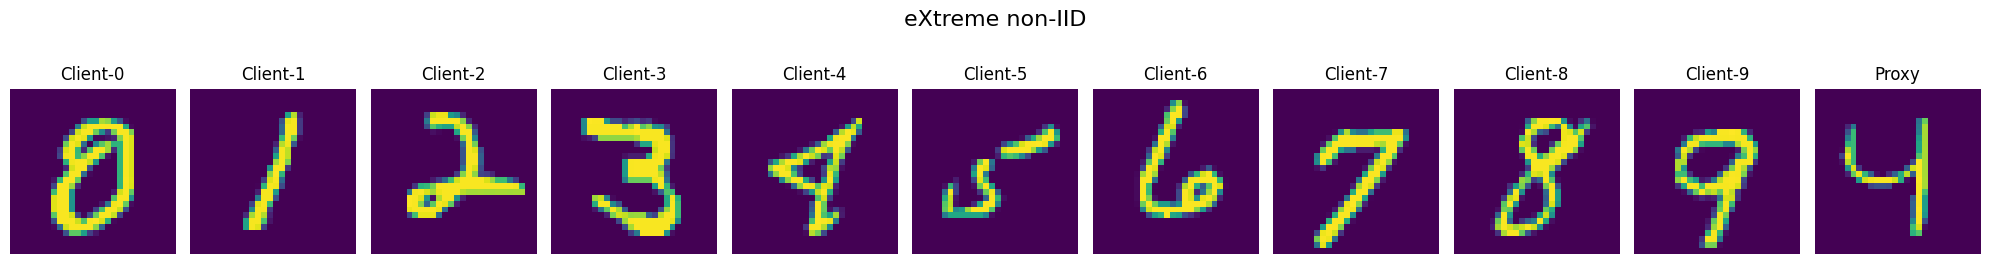

In [17]:
os.makedirs('tmp/MNIST', exist_ok=True)

transforms_fn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist = datasets.MNIST(root='tmp/MNIST', train=True, transform=transforms_fn, download=True)
mnist_test = datasets.MNIST(root='tmp/MNIST', train=False, transform=transforms_fn, download=True)

do(mnist, mnist_test, os.path.join(OUTPUT_PATH, 'mnist.pt'))

## FashionMNIST

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:17<00:00, 1.54MB/s]


Extracting tmp/FashionMNIST/FashionMNIST/raw/train-images-idx3-ubyte.gz to tmp/FashionMNIST/FashionMNIST/raw



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 472kB/s]


Extracting tmp/FashionMNIST/FashionMNIST/raw/train-labels-idx1-ubyte.gz to tmp/FashionMNIST/FashionMNIST/raw



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:03<00:00, 1.34MB/s]


Extracting tmp/FashionMNIST/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to tmp/FashionMNIST/FashionMNIST/raw



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 784kB/s]


Extracting tmp/FashionMNIST/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to tmp/FashionMNIST/FashionMNIST/raw



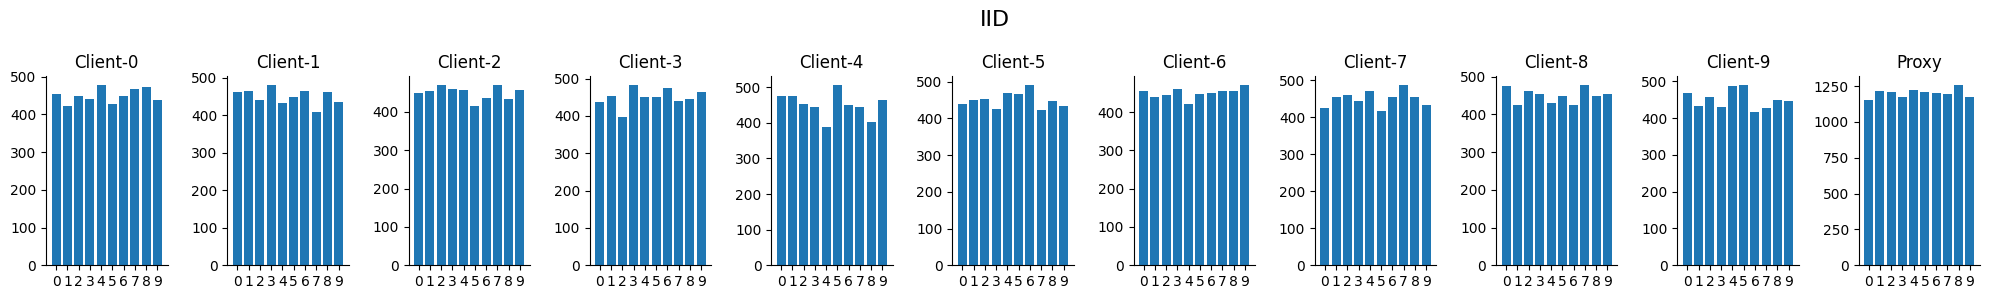

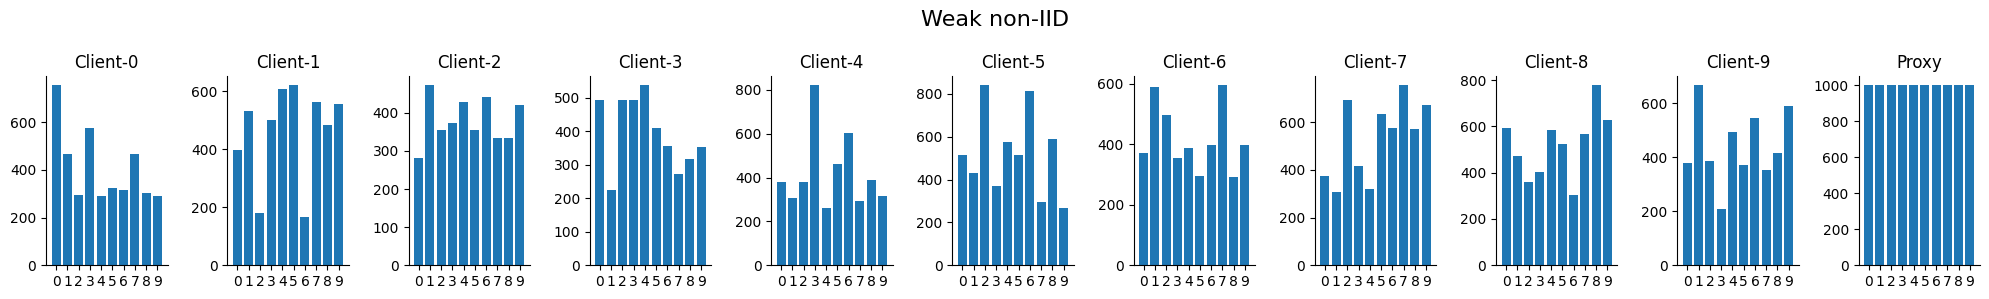

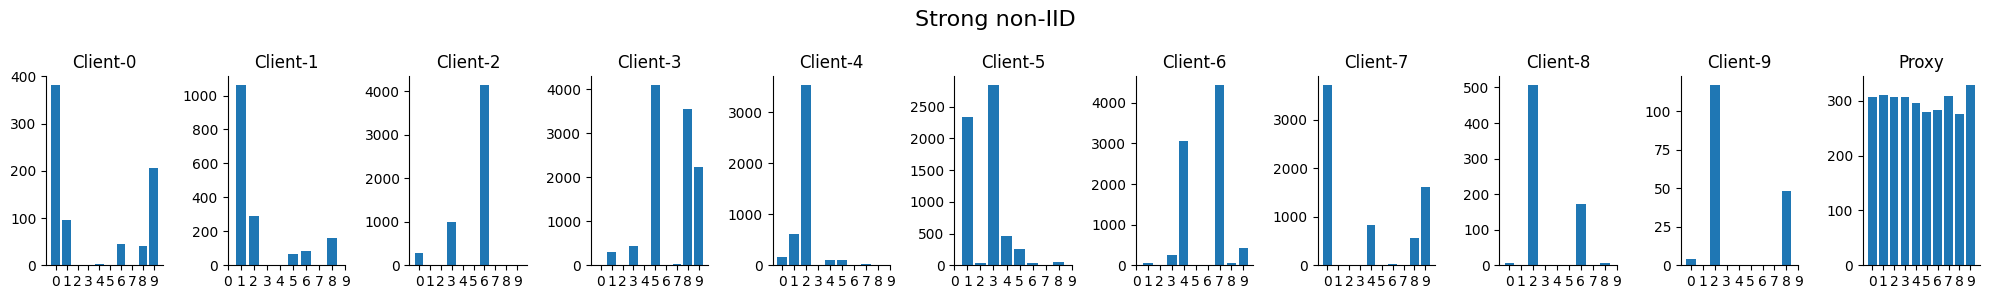

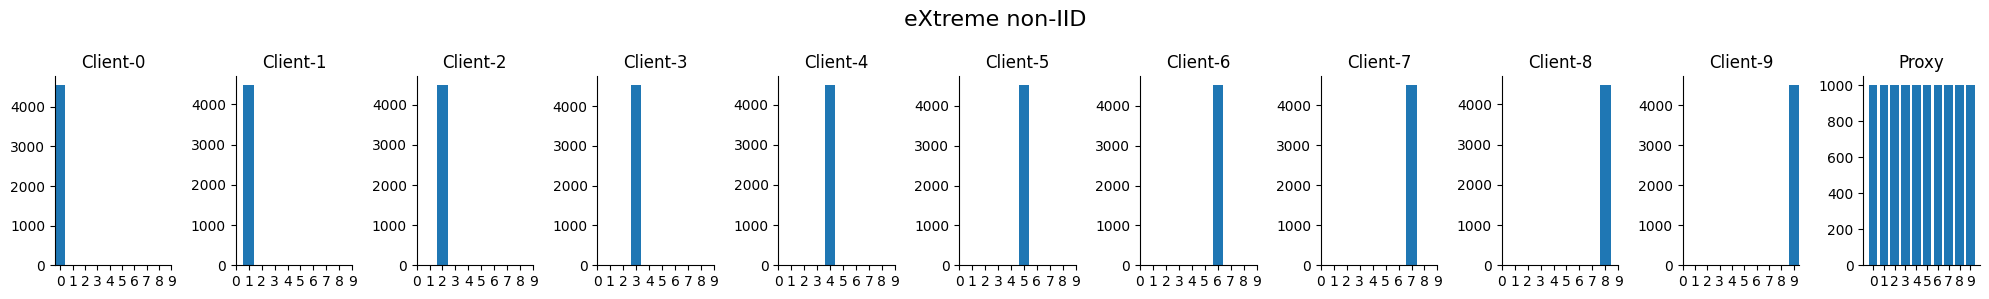

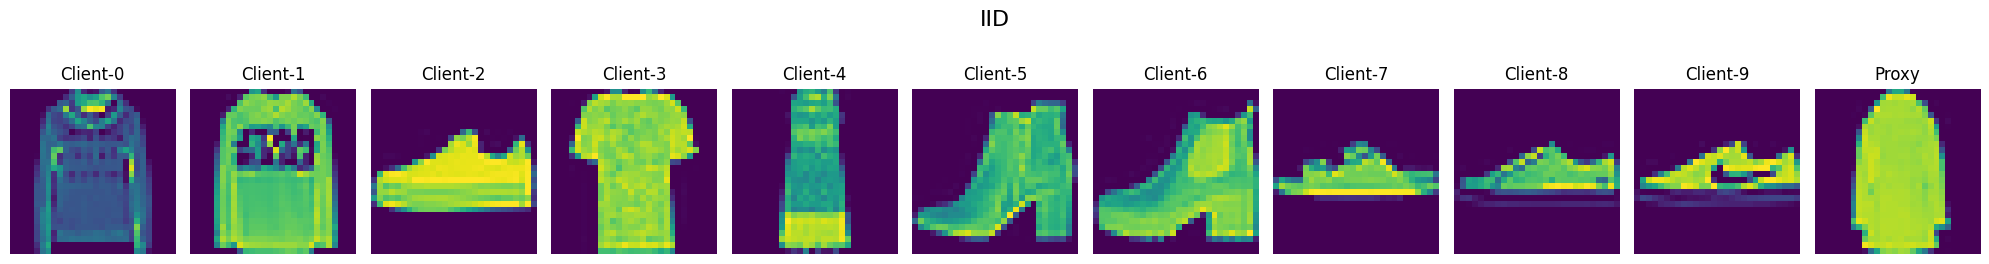

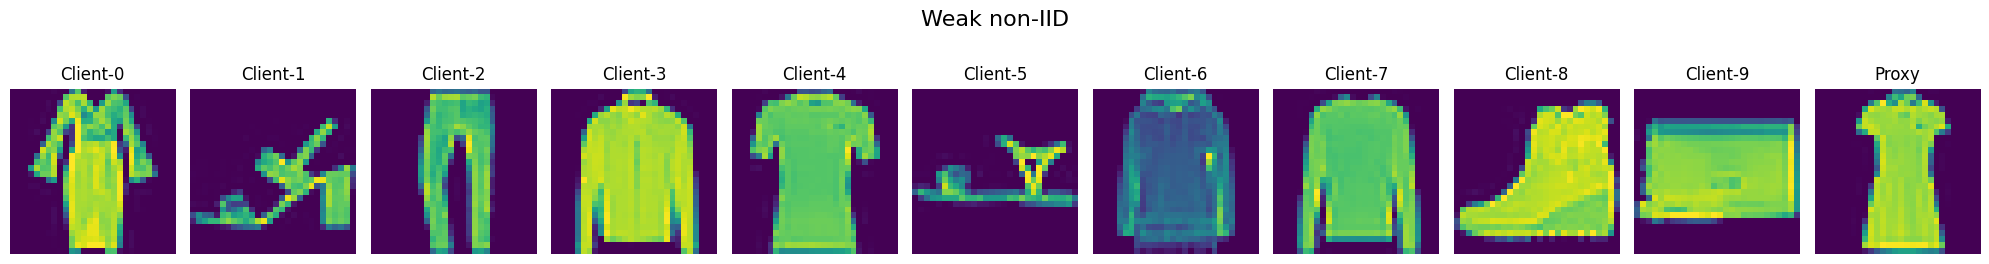

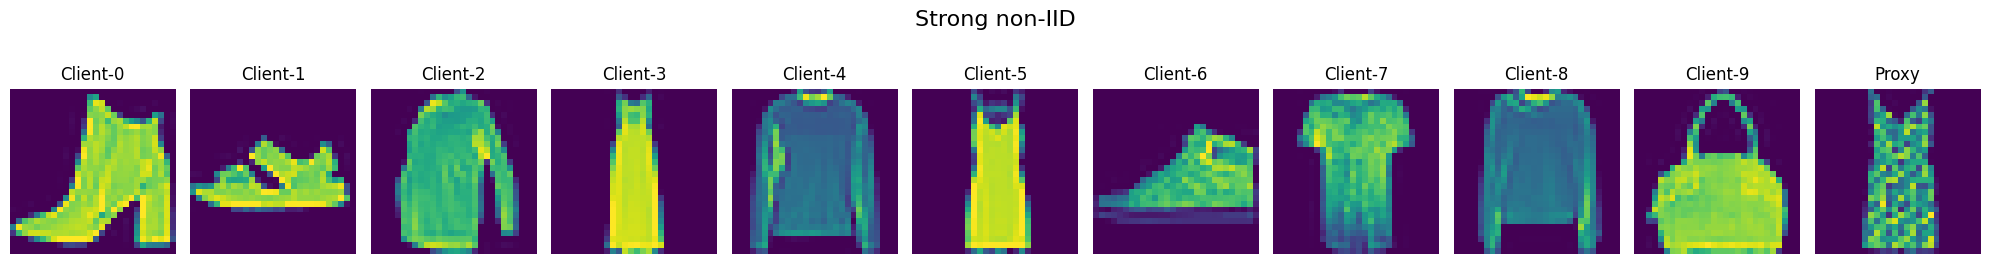

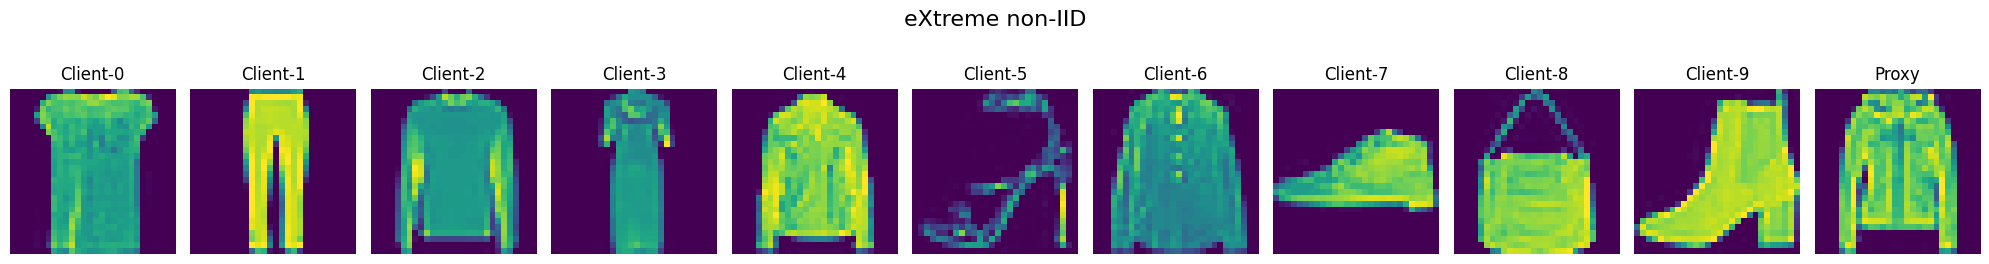

In [18]:
os.makedirs('tmp/FashionMNIST', exist_ok=True)

transforms_fn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

fmnist = datasets.FashionMNIST(root='tmp/FashionMNIST', train=True, transform=transforms_fn, download=True)
fmnist_test = datasets.FashionMNIST(root='tmp/FashionMNIST', train=False, transform=transforms_fn, download=True)


do(fmnist, fmnist_test, os.path.join(OUTPUT_PATH, 'fashion-mnist.pt'))